In [1]:
import pickle
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.chdir("/home1/beigejin/CMR-IA/Modeling/fitting/")
from optimization_utils import param_vec_to_dict

In [2]:
err_list = glob.glob(f"outfiles/err*")
all_iters = [int(err.lstrip("outfiles/err_iter")) for err in err_list]
max_iter = max(all_iters)
max_iter

100

In [3]:
file_list = glob.glob(f"outfiles/*data*.pkl")
fit_iter_part = [i.replace(f"outfiles/", "").replace(".pkl", "") for i in file_list]
fit_iter_part = [tuple(map(int, i.split("data"))) for i in fit_iter_part]
fit_iter_part.sort()
fit_iter_part = [i for i in fit_iter_part if i[0] <= max_iter]
# fit_iter_part

In [4]:
pso_df = pd.DataFrame(columns=["iter", "particle", "err"])

for iter, p in fit_iter_part:
    path = f"outfiles/{iter}data{p}.pkl"
    with open(path, "rb") as inp:
        data = pickle.load(inp)
    try:
        err = data["err"]
        b = data["params"][3]
    except:
        err = np.nan
        b = np.nan
    pso_df = pd.concat([pso_df, pd.DataFrame({"iter": [iter], "particle": [p], "err": [err], "para": [b]})])
pso_df

,iter,particle,err,para
0,1,0,14.692144,0.443140
0,1,1,30.473336,0.135913
0,1,2,12.612620,0.224589
0,1,3,14.692144,0.487087
0,1,4,14.692144,0.471917
...,...,...,...,...
0,100,195,0.108224,0.990632
0,100,196,0.171025,0.990222
0,100,197,0.655955,0.988629
0,100,198,NaN,NaN


In [5]:
pso_df["iter"] = pd.to_numeric(pso_df["iter"])

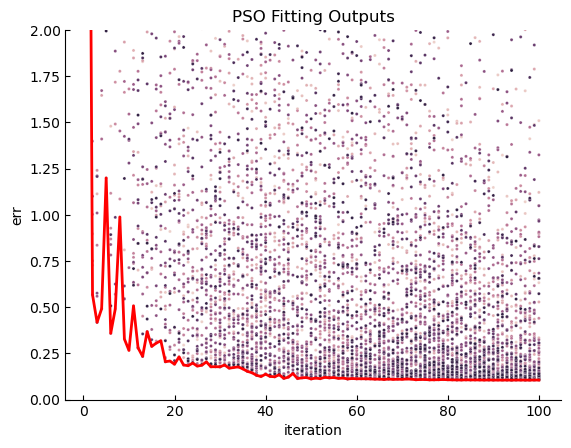

In [6]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="err", hue="particle", s=5)
plt.plot(pso_df.groupby("iter").err.min(), lw=2, color="r")
plt.ylabel("err")
plt.xlabel("iteration")
plt.ylim([0, 2])
ax.legend().set_visible(False)
plt.title("PSO Fitting Outputs")
plt.show()

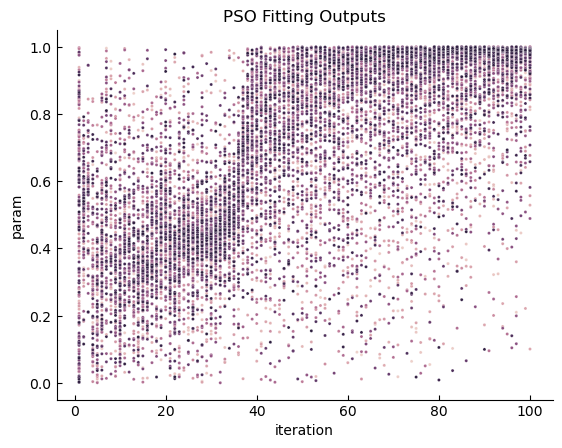

In [7]:
fig, ax = plt.subplots()
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.scatterplot(data=pso_df, x="iter", y="para", hue="particle", s=5)
# plt.plot(pso_df.groupby("iter").err.min(), lw=2, color="r")
plt.ylabel("param")
plt.xlabel("iteration")
# plt.ylim([400000, 600000])
ax.legend().set_visible(False)
plt.title("PSO Fitting Outputs")
plt.show()